In [1]:
import re
import pandas as pd
import numpy as np
import nltk

In [67]:
script = pd.read_csv("C://Users//Nandhika//Desktop//LegallyBlonde//data//cleaned_df_of_script.csv")

In [3]:
script.head(5)

,line_id,speaker,type,text
0,1,NARRATOR,scene_heading,INT. DELTA GAMMA HOUSE - DAY ...
1,2,NARRATOR,scene_description,"flock of abstract, silky, golden strands -- PU..."
2,32,NARRATOR,scene_heading,INT. ELLE'S DELTA GAMMA ROOM - DAY - CONTINUOU...
3,33,NARRATOR,scene_description,"The CARD slides into the pink room, hitting th..."
4,41,NARRATOR,scene_description,"As he rises, we RISE WITH HIM, passing toned, ..."


In [68]:
script = script.drop(['line_id'],axis=1)
script.head(3)

,speaker,type,text
0,NARRATOR,scene_heading,INT. DELTA GAMMA HOUSE - DAY ...
1,NARRATOR,scene_description,"flock of abstract, silky, golden strands -- PU..."
2,NARRATOR,scene_heading,INT. ELLE'S DELTA GAMMA ROOM - DAY - CONTINUOU...


In [9]:
script.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3251 entries, 0 to 3250
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   speaker  3251 non-null   object
 1   type     3251 non-null   object
 2   text     3251 non-null   object
dtypes: object(3)
memory usage: 76.3+ KB


In [10]:
script['speaker'].value_counts()

speaker
ELLE                                                       1173
EMMETT                                                      192
WARNER                                                      162
DONOVAN                                                     158
PROFESSOR STROMWELL                                         123
                                                           ... 
AT THE DEFENSE TABLE                                          1
BROOKE                            .'..'                       1
REPORTER                                                      1
ELLE           ..                                     .       1
NERVOUS 1L GIRL                                               1
Name: count, Length: 150, dtype: int64

In [ ]:
# Clean speaker column
script['speaker'] = (
    script['speaker']
    .astype(str)                      # ensure all are strings
    .str.strip()                      # remove leading/trailing spaces
    .str.replace(r'[^A-Za-z]', '', regex=True)  # remove special characters
    .str.upper()                      # convert to uppercase
)

In [69]:
# Clean text column
script['text'] = (
    script['text']
    .astype(str)                      # ensure all are strings
    .str.replace(r'INT','')                     # convert to uppercase
)

In [70]:
script['speaker'].value_counts()

speaker
ELLE                                                  1182
EMMETT                                                 192
WARNER                                                 162
DONOVAN                                                158
PROFESSOR STROMWELL                                    123
                                                      ... 
'                ELLE                                    1
"^                                  BROOKE               1
BROOKE                            .'..'                  1
ELLE                                             '       1
NERVOUS 1L GIRL                                          1
Name: count, Length: 149, dtype: int64

In [71]:
filtered_df = script[script['speaker'].isin(["WARNER", "EMMETT"])]

In [72]:
filtered_df = filtered_df.reset_index(drop=True)

In [17]:
filtered_df.head(5)

,speaker,type,text
0,WARNER,dialogue,You're beautiful.
1,WARNER,stage_direction,(nervous)
2,WARNER,dialogue,You ready?
3,WARNER,dialogue,Her face is awash with devotion.
4,WARNER,dialogue,The reason I wanted to come here tonight


In [18]:
filtered_df.shape

(372, 3)

In [15]:
filtered_df['speaker'].value_counts()

speaker
EMMETT    199
WARNER    173
Name: count, dtype: int64

In [19]:
filtered_df= filtered_df.drop(['type'],axis=1)
filtered_df.head(3)

,speaker,text
0,WARNER,You're beautiful.
1,WARNER,(nervous)
2,WARNER,You ready?


### Classification of WARNER and EMMETT dialogues from Legally Blonde using BOW and TF-IDF

In [20]:
fd = filtered_df
fd.head(3)


,speaker,text
0,WARNER,You're beautiful.
1,WARNER,(nervous)
2,WARNER,You ready?


In [21]:
import nltk
import re
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nandhika\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [24]:
# Cleaning
corpus = []
for i in range(0,len(fd)):
    review = re.sub('[^a-zA-Z]',' ',fd['text'][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if word not in stopwords.words('english')]
    review = ''.join(review)
    corpus.append(review)

In [27]:
# Splitting the data into independent and dependent features
y = pd.get_dummies(fd['speaker'])
y = y.iloc[:,0].values

In [28]:
# Splitting into train test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(corpus,y,test_size=0.2,random_state=43)

In [ ]:
# Bag of words
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=150, ngram_range=(3,2))
X_train = cv.fit_transform(X_train).toarray()
X_test = cv.transform(X_test).toarray()

In [30]:
# Model Training
from sklearn.naive_bayes import MultinomialNB
speaker_model = MultinomialNB().fit(X_train,y_train)

In [31]:
y_pred = speaker_model.predict(X_test)

In [32]:
## Model Evaluation
from sklearn.metrics import classification_report, accuracy_score
accuracy_score(y_test,y_pred)

0.5333333333333333

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00        33
        True       0.55      0.95      0.70        42

    accuracy                           0.53        75
   macro avg       0.27      0.48      0.35        75
weighted avg       0.31      0.53      0.39        75



In [3]:
script.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3251 entries, 0 to 3250
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   line_id  3251 non-null   int64 
 1   speaker  3251 non-null   object
 2   type     3251 non-null   object
 3   text     3251 non-null   object
dtypes: int64(1), object(3)
memory usage: 101.7+ KB


In [9]:
filtered_df['speaker'].value_counts()

speaker
EMMETT    199
WARNER    173
Name: count, dtype: int64

## TFIDF

In [14]:
import re
from nltk.stem.porter import PorterStemmer
import nltk
nltk.download("stopwords")
ps = PorterStemmer()
from nltk.stem import WordNetLemmatizer
lem = WordNetLemmatizer()
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nandhika\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [73]:
#Preprocessing and cleaning
filtered_df.head(2)

,speaker,type,text
0,WARNER,dialogue,You're beautiful.
1,WARNER,stage_direction,(nervous)


In [74]:
filtered_df = filtered_df.drop('type',axis=1)
filtered_df.head(2)

,speaker,text
0,WARNER,You're beautiful.
1,WARNER,(nervous)


In [75]:
corpus = []
for i in range(0,len(filtered_df)):
    # take each row from the text column and make sure if there are any other special characters other than alphabets, replace them with a whitespace
    temp = re.sub('[^a-zA-Z]',' ',filtered_df['text'][i])
    temp = temp.lower()
    # You have one sentence per loop, so you are gonna split a whole sentence into list of words
    temp = temp.split()
    # After that you are going to apply the lemmatizer on each of these words present inside the list only if they did not contain stopwords
    temp = [lem.lemmatize(word) for word in temp if word not in stopwords.words("english")]
    # Now you are going to join all these words back into a single sentence 
    temp = ' '.join(temp)
    # Now you are creating a list of sentences 
    corpus.append(temp)

In [76]:
corpus

['beautiful',
 'nervous',
 'ready',
 'face awash devotion',
 'reason wanted come tonight',
 'discus future',
 'elle edge seat',
 'mean lot fun',
 'thing gonna different',
 'harvard law school completely',
 'different world need serious',
 'family expects lot',
 'expect lot plan running',
 'office day',
 'hat think time u',
 'elle take deep breath filled anticipation',
 'think break',
 'elle champagne glass drop hand crash onto',
 'patio',
 'sorry elle',
 'proposing elle going',
 'politician need marry jackie',
 'marilyn',
 'hat entirely',
 'love elle marry',
 'idea pressure',
 'family five generation senator',
 'brother top three yale law',
 'got engaged vanderbilt crissakes',
 'elle stare aghast tear streaming face',
 'push chair away table walk',
 'continuing',
 'like choice sweetheart',
 'follows',
 'ext street night',
 'elle teeter sidewalk best three',
 'inch heel sobbing warner pull alongside',
 'convertible saab',
 'c mon let take home',
 'elle twenty mile back campus',
 'elle s

In [77]:
# Changing the target feature into zeros and ones 
filtered_df.head(2)
label_counts = filtered_df['speaker'].value_counts()

Below visualizations are adapted from [here](https://medium.com/@thommaskevin/tinyml-multinominal-naive-bayes-text-classifier-d5df9bccbd32).

Greatful for Thommaskevin

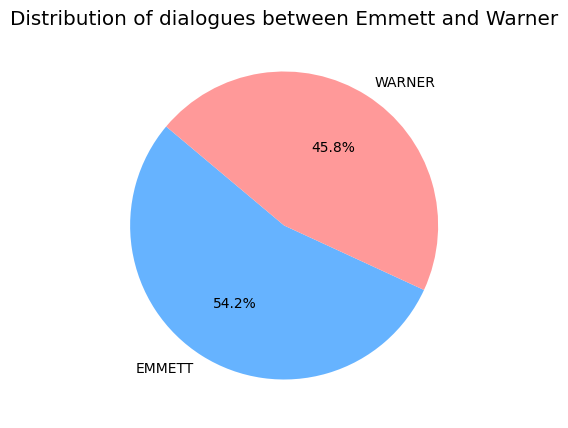

In [78]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#ff9999'])
plt.title('Distribution of dialogues between Emmett and Warner')
plt.show()

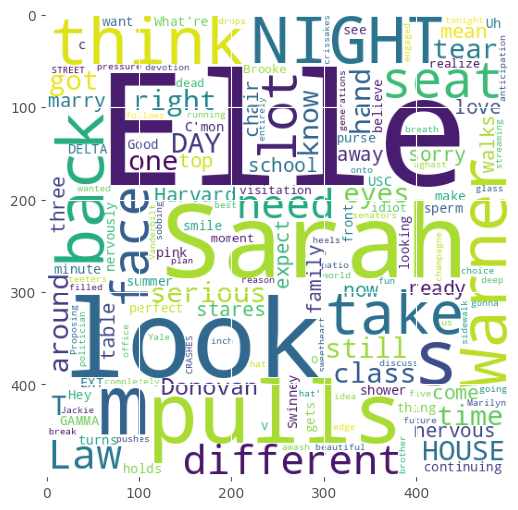

In [79]:
from wordcloud import WordCloud
plt.style.use("ggplot")
wc_spam = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')
spam_wc = wc_spam.generate(filtered_df[filtered_df['speaker'] == 'WARNER']['text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(wc_spam)
plt.show()

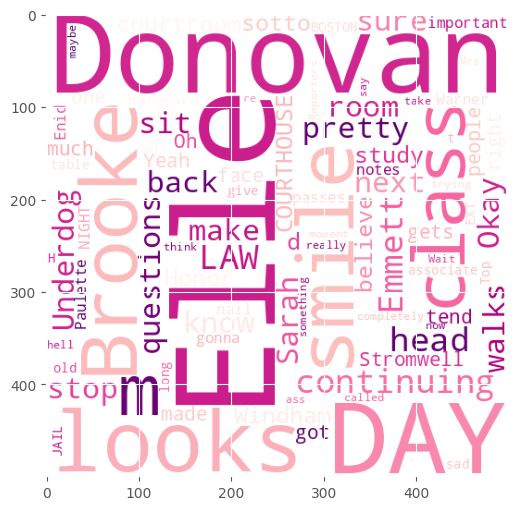

In [80]:
wc_spam = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white',colormap="RdPu")
spam_wc = wc_spam.generate(filtered_df[filtered_df['speaker'] == 'EMMETT']['text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(wc_spam)
plt.show()

In [81]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y = lb.fit_transform(filtered_df['speaker'])


In [82]:
# Train test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(corpus,y,random_state=45,test_size=0.3)

In [83]:
X_train

['nightmare typing furiously elle break nail',
 'socratic method',
 'donovan midst lecture point elle',
 'as gonna try',
 'levinson class',
 'serious',
 'according swinney v neubert swinney',
 'marilyn',
 'donovan glare emmett continue',
 'beauty oasis day',
 'allowed visitation right long',
 'kiss',
 'nervously looking sarah',
 'brooke obviously hiding',
 'since ninth grade',
 'amused',
 'murder weapon',
 'hawk crap home shopping',
 'grab warner passing',
 'really topic keep',
 'mind reeling',
 'married old man made',
 'made realize something',
 'thing gonna different',
 'move strike record',
 'smiling',
 'patio',
 'sarah horrible girl hold hand elle',
 'sotto',
 'snort',
 'pull close hand around waist kissing',
 'speed',
 'warner pull front starry romantic night',
 'want elle forever',
 'brooke heyworth',
 'scoffing',
 'something',
 'funny woman turn bitch',
 'elle turn ultra nonchalant',
 'ext courthouse day',
 'full contempt',
 'relationship',
 'leaving',
 'tear stained',
 'nervous

In [84]:
y_test

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0])

We split first to ensure the vectorizer learns vocabulary and statistics only from training data. If we fit before splitting, information from the test set leaks into the model via IDF scores or word presence, leading to overly optimistic performance.
They are feature extraction steps that learn from data: that’s why:
Cleaning (lowercase, regex, stopwords) → can be done before split
Vectorization (BoW, TF-IDF) → must be done after split

(1,1) → single words → "you", "are", "beautiful"
(2,2) → pairs → "you are", "are beautiful"
(3,3) → triples → "you are beautiful"
🧠 How it affects accuracy
✅ Smaller n-grams (1,1)
General patterns
Works well with small data
Less sparse

👉 Stable but may miss context

✅ Mixed n-grams (1,2) ← ⭐ BEST DEFAULT
Captures:
individual words
short phrases

👉 Example:

"not good" vs "good" → big difference

➡️ Usually boosts accuracy

❌ Larger n-grams (3,3)
Very specific phrases
Rare → appear very few times

👉 Leads to:

Sparse matrix
Overfitting
Lower generalization

➡️ Accuracy often drops

🔥 Intuition

n-grams = “how much context” you give the model

Too little → misses meaning
Too much → overfits

👉 Sweet spot = (1,2) or (1,3)

In [ ]:
# WE SHOULD ONLY PERFORM THE BOW AND TF-IDF (as they are also converting text to vectors (preprocessing step)) after the splitting of the dataset so that we can ensure that no data leakage happens
# Before I had only trigrams and the model was not able to predict anything
tfidf = TfidfVectorizer(ngram_range=(1,2))
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [86]:
# MODEL TRAINING
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB(alpha=0.1)
mnb.fit(X_train,y_train)
tfidf_y_pred = mnb.predict(X_test)

In [87]:
# MODEL EVALUATION
from sklearn.metrics import classification_report
print(classification_report(y_pred=tfidf_y_pred,y_true=y_test))

              precision    recall  f1-score   support

           0       0.58      0.69      0.63        61
           1       0.46      0.35      0.40        46

    accuracy                           0.54       107
   macro avg       0.52      0.52      0.51       107
weighted avg       0.53      0.54      0.53       107



In [88]:
tfidf_y_pred

array([1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [89]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, tfidf_y_pred))

0.5420560747663551


### ALTERNATE APPROACH WITH PIPELINE AND TUNING

In [104]:
script = pd.read_csv("C://Users//Nandhika//Desktop//LegallyBlonde//data//cleaned_df_of_script.csv")
script = script.drop(['line_id'],axis=1)
script.head(3)
# Clean speaker column
script['speaker'] = (
    script['speaker']
    .astype(str)                      # ensure all are strings
    .str.strip()                      # remove leading/trailing spaces
    .str.replace(r'[^A-Za-z]', '', regex=True)  # remove special characters
    .str.upper()                      # convert to uppercase
)
# Clean text column
script['text'] = (
    script['text']
    .astype(str)                      # ensure all are strings
    .str.replace(r'INT','')                     # convert to uppercase
)
filtered_df['text'] = filtered_df['text'].str.replace(r'\bcontinuing\b', '', regex=True)
filtered_df['text'] = filtered_df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()
filtered_df = script[script['speaker'].isin(["WARNER", "EMMETT"])]
filtered_df = filtered_df.reset_index(drop=True)
filtered_df = filtered_df.drop('type',axis=1)
corpus = []
for i in range(0,len(filtered_df)):
    # take each row from the text column and make sure if there are any other special characters other than alphabets, replace them with a whitespace
    temp = re.sub('[^a-zA-Z]',' ',filtered_df['text'][i])
    temp = temp.lower()
    # You have one sentence per loop, so you are gonna split a whole sentence into list of words
    temp = temp.split()
    # After that you are going to apply the lemmatizer on each of these words present inside the list only if they did not contain stopwords
    temp = [lem.lemmatize(word) for word in temp if word not in stopwords.words("english")]
    # Now you are going to join all these words back into a single sentence 
    temp = ' '.join(temp)
    # Now you are creating a list of sentences 
    corpus.append(temp)
# Changing the target feature into zeros and ones 
filtered_df.head(2)
label_counts = filtered_df['speaker'].value_counts()
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y = lb.fit_transform(filtered_df['speaker'])
# Train test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(corpus,y,random_state=45,test_size=0.3)


#### f1_macro vs f1 in binary
 - f1_macro: Computes F1 for each class separately (positive and negative), then averages them equally ignoring class imbalance
- F1_macro = (F1_class0 + F1_class1) / 2

In [105]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

# Step 1: Create pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

# Step 2: Define parameter grid
param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2), (1,3)],
    'tfidf__max_df': [0.8, 0.9, 1.0],
    'tfidf__min_df': [1, 2, 5],
    'nb__alpha': [0.01, 0.1, 1, 5]
}

# Step 3: Grid Search
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',   # best metric for your case
    n_jobs=-1
)

# Step 4: Train
grid.fit(X_train, y_train)

# Step 5: Best params
print("Best Params:", grid.best_params_)

# Step 6: Predict
y_pred = grid.predict(X_test)

# Step 7: Evaluation
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Params: {'nb__alpha': 1, 'tfidf__max_df': 0.8, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Accuracy: 0.5803571428571429
              precision    recall  f1-score   support

           0       0.57      0.83      0.68        59
           1       0.62      0.30      0.41        53

    accuracy                           0.58       112
   macro avg       0.59      0.57      0.54       112
weighted avg       0.59      0.58      0.55       112



In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)

#### Factors that affect the number of features
- Vocabulary size → more unique words = more features
- n-gram range
ngram_range	Example	More features?
- (1,1)	single words	moderate
- (1,2)	unigrams + bigrams	more features
- (1,3)	unigrams + bi + trigrams	even more, very sparse
- min_df / max_df
- TfidfVectorizer(min_df=2, max_df=0.9)
- min_df → ignores rare words → reduces features
- max_df → ignores very common words → reduces features

IT-IDF It extracts one feature per unique word or n-gram in the training data, filtered by parameters like min_df, max_df, and ngram_range. This typically results in thousands to tens of thousands of features, all represented as a sparse matrix.

In [97]:
# Trying to see the number of features generated by tfidf
X_train_tfidf.shape
# (num_samples, num_features)

(260, 471)

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1,2))  # example
X_train_tfidf = tfidf.fit_transform(X_train)

In [102]:
import numpy as np

# 1. get feature names
feature_names = tfidf.get_feature_names_out()

# 2. sum TF-IDF scores across all sentences
tfidf_sum = X_train_tfidf.sum(axis=0).A1  # 1D array

# 3. get top 20 features
top20_idx = tfidf_sum.argsort()[-20:][::-1]

print("Top 20 features in corpus:")
for idx in top20_idx:
    print(feature_names[idx], tfidf_sum[idx])

Top 20 features in corpus:
elle 7.008573680079263
continuing 4.880982321054567
donovan 4.730546510936196
think 3.902880903982632
look 3.1088667446172122
serious 3.0
know 2.7619315459865623
day 2.7264152723505153
right 2.564026309714155
class 2.374279494023725
sarah 2.315343945928214
nervous 2.0
gonna 1.9925241493427286
thing 1.9925241493427286
brooke 1.9921484979051276
night 1.8824529059862285
time 1.837071341364457
sure 1.8190487731678895
one 1.7588853896254175
believe 1.755350929959983


In [103]:
# pick first sentence
doc_vector = X_train_tfidf[0].toarray()[0]  # convert sparse row to array

top_n_idx = doc_vector.argsort()[-10:][::-1]

print("Top features in first sentence:")
for idx in top_n_idx:
    print(feature_names[idx], doc_vector[idx])

Top features in first sentence:
bu maybe 0.5906258243318936
bu 0.5906258243318936
maybe 0.5498384046831781
year 0.0
yeah tend 0.0
yeah pretty 0.0
yeah 0.0
yale law 0.0
yale 0.0
wow walking 0.0


#### TRYING OUT LOGISTIC REGRESSION

In [106]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression(max_iter=1000))
])


# Parameters
param_grid = {
    'tfidf__ngram_range': [(1,2), (1,3)],
    'lr__C': [0.1, 1, 10]
}

# Step 3: Grid Search
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',   # best metric for your case
    n_jobs=-1
)

# Step 4: Train
grid.fit(X_train, y_train)

# Step 5: Best params
print("Best Params:", grid.best_params_)

# Step 6: Predict
y_pred = grid.predict(X_test)

# Step 7: Evaluation
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Params: {'lr__C': 1, 'tfidf__ngram_range': (1, 3)}
Accuracy: 0.5357142857142857
              precision    recall  f1-score   support

           0       0.54      0.78      0.64        59
           1       0.52      0.26      0.35        53

    accuracy                           0.54       112
   macro avg       0.53      0.52      0.49       112
weighted avg       0.53      0.54      0.50       112

